Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name, email and UFID.
Please do not modify instruction cells or any cells with automated tests (marked with `[ASSERTS]`). Note: you can add new cells if you need them, but answers must be in the cells with `YOUR CODE HERE` or "YOUR ANSWER HERE" comments.

---

## Homework 4: Training Neural Networks

## Preamble: Write your Name, Email and UFID

In [1]:
NAME = 'Tikaharu Sharma'
EMAIL = 'tikaharusharma@ufl.edu'
UFID = 73535666

# YOUR CODE HERE

print('Homework 4 -- name: {}, email: {}, UFID: {}\n'.format(NAME, EMAIL, UFID))

Homework 4 -- name: Tikaharu Sharma, email: tikaharusharma@ufl.edu, UFID: 73535666



In [2]:
""" [ASSERTS] Check that your name, email, and UFID is filled in."""
assert NAME != '' and NAME != 'Your name here.' and len(NAME) > 3
assert EMAIL != '' and EMAIL != 'Your email here.' and len(EMAIL) > 7
assert type(UFID) == int and UFID != 12345678 and UFID >= 10000000 and UFID <= 99999999

## Academic Integrity

### <span style="color:red;">This is an individual assignment. Academic integrity violations (i.e., cheating, plagiarism) will be reported to SCCR!</span><br/>
#### The official CISE policy recommended for such offenses is a course grade of E. Additional sanctions may be imposed by SCCR such as marks on your permanent educational transcripts, dismissal or expulsion.
#### Reminder of the Honor Pledge: On all work submitted for credit by Students at the University of Florida, the following pledge is either required or implied: *"On my honor, I have neither given nor received unauthorized aid in doing this assignment."*

#### Acknowledgement: Do you acknowledge and understand the academic integrity warning above? 

In [3]:
academic_integrity_acknowledgement = True
# YOUR CODE HERE


In [4]:
""" [ASSERTS] Check that you acknowledge the academic integrity warning, you understand it and have been reminded of the UF Honor Pledge."""
assert academic_integrity_acknowledgement

#### The following cell's code (import statements etc.) is provided for you and you should not need to change it.

In [5]:
# Load packages we need
import sys
import os
import time

import numpy as np
import pandas as pd
import sklearn

# pytorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

from matplotlib import pyplot as plt
plt.rcParams.update({'font.size': 10})

# Let's check our software versions
print('------------')
print('### Python version: ' + __import__('sys').version)
print('### NumPy version: ' + np.__version__)
print('### Scikit-learn version: ' + sklearn.__version__)
print('### PyTorch version: ' + torch.__version__)
print('------------')

def var_exists(var_name):
    return (var_name in globals() or var_name in locals())


------------
### Python version: 3.10.19 (main, Oct 21 2025, 16:37:10) [Clang 20.1.8 ]
### NumPy version: 2.2.5
### Scikit-learn version: 1.7.2
### PyTorch version: 2.9.1
------------


#### This is the seed we will use, do not change it.

In [6]:
# set the seed
seed = 42
np.random.seed(seed)

epsf = 1e-9 # small epsilon value for floating point comparisons

In [7]:
""" [ASSERTS] Check seed. """
assert seed == 42

### We will use the Fashion-MNIST dataset

### Loading data

In [8]:
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import numpy as np

"""
## Load and preprocess Fashion-MNIST
"""
def load_preprocess_fmnist_data(flatten=True, onehot=True, val_prop=0.5, seed=None, num_classes=10, verbose=False):
    
    # Download the dataset using torchvision
    transform = transforms.ToTensor()  # converts PIL images to [0,1] torch.Tensor
    train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    
    # Extract data from the datasets.
    # The .data attribute is a Tensor with shape (n, 28, 28)
    x_train = train_dataset.data.numpy()
    y_train = train_dataset.targets.numpy()
    x_test  = test_dataset.data.numpy()
    y_test  = test_dataset.targets.numpy()
    
    assert x_train.shape == (60000, 28, 28) and x_test.shape == (10000, 28, 28)
    assert y_train.shape == (60000,) and y_test.shape == (10000,)
    
    if verbose:
        print('Loaded Fashion-MNIST data; shape: {} [y: {}], test shape: {} [y: {}]'.format(x_train.shape, y_train.shape,
                                                                                              x_test.shape, y_test.shape))
    
    if flatten: # flatten images for easier processing
        flat_vec_size = 28 * 28
        train_x = x_train.reshape(x_train.shape[0], flat_vec_size)
        test_x  = x_test.reshape(x_test.shape[0], flat_vec_size)
    
    if onehot:  # convert to one-hot encoding
        train_y = np.eye(num_classes)[y_train]  
        test_y  = np.eye(num_classes)[y_test]   
    
    # we'll split the test set into validation and test sets
    testval_x = test_x
    testval_y = test_y
    
    # The test_size=val_prop splits the testval into (1-val_prop) and val_prop portions.
    val_x, test_x, val_y, test_y = train_test_split(testval_x, testval_y, test_size=val_prop, random_state=seed)
    
    return train_x, train_y, test_x, test_y, val_x, val_y

# Grab the data
train_x, train_y, test_x, test_y, val_x, val_y = load_preprocess_fmnist_data(flatten=True, onehot=True, val_prop=0.5, seed=seed)

# Sanity check shapes
print(train_x.shape, train_y.shape, test_x.shape, test_y.shape, val_x.shape, val_y.shape)
assert train_x.shape == (60000, 784) and train_y.shape == (60000, 10) and test_x.shape == (5000, 784) and test_y.shape == (5000, 10)

(60000, 784) (60000, 10) (5000, 784) (5000, 10) (5000, 784) (5000, 10)


## First, let's setup some performance evaluation and plotting code

In [9]:
# Let's create a custom callback class
class PerfEvalCustomCallback:
    
    def __init__(self, perf_data):
        self.perf_data = perf_data
    
    # we define the on_epoch_end callback and save the loss and accuracy in perf_data
    def on_epoch_end(self, epoch, logs=None):
        self.perf_data[epoch, 0] = logs['loss']
        self.perf_data[epoch, 1] = logs['accuracy']
        self.perf_data[epoch, 2] = logs['val_loss']
        self.perf_data[epoch, 3] = logs['val_accuracy']

    def get_perf_data(self):
        return self.perf_data

In [10]:
# Plot the model's performance during training (across epochs)
def plot_training_perf(train_loss, train_acc, val_loss, val_acc, ax=None, fs=(5.5,2.8), plot_acc=True):
    no_ax_provided = ax == None
    if no_ax_provided:
        fig = plt.figure(figsize=fs)
        ax = plt.gca()

    assert train_loss.shape == val_loss.shape and train_loss.shape == val_acc.shape and val_acc.shape == train_acc.shape
    
    # assume we have one measurement per epoch
    num_epochs = train_loss.shape[0]
    epochs = np.arange(0, num_epochs)

    if plot_acc:
        ax.plot(1+epochs, train_acc, 'r--', linewidth=1.5, label='Training')
        ax.plot(1+epochs, val_acc, 'b-', linewidth=1.5, label='Validation')
        
        ax.set_ylabel('Accuracy')
        ax.set_xlabel('Epoch')
    else:
        ax.plot(1+epochs, train_loss, 'r--', linewidth=1.5, label='Training')
        ax.plot(1+epochs, val_loss, 'b-', linewidth=1.5, label='Validation')
        
        ax.set_ylabel('Loss')
        ax.set_xlabel('Epoch')
    
    ax.set_xlim([1, num_epochs])

    if plot_acc:
        ylim = [0.0, 1.01]
    else:
        ylim = [0.0, 2.01]
    ax.set_ylim(ylim)

    ax.legend()
    if no_ax_provided:
        plt.show()

---
# [Task 1] (15 points) Complete (& Customize) Your Model Training and Evaluation Code

### [Task 1a] (15 points) Complete the implementation of evaluate_model(). You can customize it to add whatever evaluation functionality you like (e.g., classification report, error analysis, etc.). Make sure you like the way it shows you the information: you will use it throughout this homework!

In [11]:
"""Fill in your code in the function (~6+ lines)
"""
# Customize this function as you like but make sure it is implemented correctly.    
# Note: If you need to change the method definition to add more arguments, make sure to make 
# the new arguments are optional (& have a sensible default value)

def evaluate_model(name, model, eval_data, plot_training=True, evaluate_on_test_set=True):
    # unpack the stuff
    perf_data, dataset = eval_data
    train_x, train_y, val_x, val_y, test_x, test_y = dataset
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # gpu if available else cpu
    model.to(device)
    model.eval() # put model in eval mode
    
    # Convert training and validation data to torch tensors
    train_tensor = torch.tensor(train_x, dtype=torch.float32).to(device)
    val_tensor = torch.tensor(val_x, dtype=torch.float32).to(device)
    
    # Convert one-hot labels to indices if needed
    if train_y.ndim > 1:
        train_y_indices = np.argmax(train_y, axis=1)
    else:
        train_y_indices = train_y
        
    if val_y.ndim > 1:
        val_y_indices = np.argmax(val_y, axis=1)
    else:
        val_y_indices = val_y
    
    with torch.no_grad():
        train_logits = model(train_tensor)
        val_logits = model(val_tensor)
    
    # Grab predictions and calculate accuracy as proportion of correct predictions
    # YOUR CODE HERE
    train_labels = torch.tensor(train_y_indices, dtype=torch.long).to(device)
    val_labels = torch.tensor(val_y_indices, dtype=torch.long).to(device)

    train_preds = torch.argmax(train_logits, dim=1)
    val_preds = torch.argmax(val_logits, dim=1)

    train_acc = (train_preds == train_labels).float().mean().item()
    val_acc = (val_preds == val_labels).float().mean().item()
    
    # Check that accuracies are in a valid range
    assert np.isnan(train_acc) or (float(train_acc) == train_acc and train_acc >= 0 and train_acc <= 1.0)
    assert np.isnan(val_acc) or (float(val_acc) == val_acc and val_acc >= 0 and val_acc <= 1.0)
    
    print('[{}] Training Accuracy: {:.3f}%, Validation Accuracy: {:.3f}%'.format(name, 100*train_acc, 100*val_acc))
        
    if evaluate_on_test_set:
        
        # Evaluation on the test set
        test_tensor = torch.tensor(test_x, dtype=torch.float32).to(device)
        
        if test_y.ndim > 1:
            test_y_indices = np.argmax(test_y, axis=1)
        else:
            test_y_indices = test_y
            
        test_labels = torch.tensor(test_y_indices, dtype=torch.long).to(device)
        
        criterion = nn.CrossEntropyLoss()
        model.eval()
        
        with torch.no_grad():
            test_logits = model(test_tensor)
            test_loss = criterion(test_logits, test_labels).item()
            
        # YOUR CODE HERE
        test_preds = torch.argmax(test_logits, dim=1)
        test_acc = (test_preds == test_labels).float().mean().item()
        
        assert np.isnan(test_loss) or (test_loss == float(test_loss) and test_loss >= -1e8)
        assert np.isnan(test_acc) or (test_acc == float(test_acc) and test_acc >= 0 and test_acc <= 1.0)
    
        print('[{}] Test loss: {:.5f}, test accuracy: {:.3f}%'.format(name, test_loss, 100*test_acc))
    
    if plot_training:
        plot_training_perf(perf_data[:,0], perf_data[:,1], perf_data[:,2], perf_data[:,3])
    
    # You can add any additional code here if desired
    # YOUR CODE HERE
    
    return


# Compute count of correct predictions from model outputs and (true) labels (works with CE and MSE)
def correct_preds(model, outputs, labels):
    _, predicted = torch.max(outputs, 1)

    if isinstance(model.loss_func, torch.nn.MSELoss):
        # Note: for MSELoss, both outputs and labels are one-hot vectors.
        _, labels = torch.max(labels, 1)
    
    correct_count = (predicted == labels).sum().item()
    return correct_count
    

def train_model(model, max_epochs=15, batch_size=256, verbose=0, dataset=None): # train the model for that number of epochs
    if dataset is None or type(dataset) != tuple or len(dataset) != 6:
        raise ValueError("Expected a dataset tuple: (train_x, train_y, val_x, val_y, test_x, test_y)")

    train_x, train_y, val_x, val_y, test_x, test_y = dataset # unpack
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    # Convert labels depending on the loss function used
    if isinstance(model.loss_func, torch.nn.CrossEntropyLoss):
        # For CrossEntropyLoss, convert one-hot labels to indices.
        train_labels = torch.tensor(np.argmax(train_y, axis=1), dtype=torch.long)
        val_labels = torch.tensor(np.argmax(val_y, axis=1), dtype=torch.long)
        test_labels = torch.tensor(np.argmax(test_y, axis=1), dtype=torch.long)
    else:
        # For MSELoss, use the one-hot labels as floats.
        train_labels = torch.tensor(train_y, dtype=torch.float32)
        val_labels = torch.tensor(val_y, dtype=torch.float32)
        test_labels = torch.tensor(test_y, dtype=torch.float32)
    
    #  DataLoaders for training and validation sets
    train_dataset = torch.utils.data.TensorDataset(torch.tensor(train_x, dtype=torch.float32), train_labels)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    val_dataset = torch.utils.data.TensorDataset(torch.tensor(val_x, dtype=torch.float32), val_labels)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Use the loss function provided by the model
    
    criterion = model.loss_func
    try:
        optimizer = model.optimizer
        
    except AttributeError:
        optimizer = optim.Adam(model.parameters(), lr=model.learning_rate) # force Adam optimizer if not specified (use learning rate set as model.learning_rate).
        
    # Setup the performance data callback (this is the custom callback we defined earlier)
    perf_data = np.zeros((max_epochs, 4))
    perf_eval_cb = PerfEvalCustomCallback(perf_data)
    
    # Training loop (note: no early stopping implemented)
    for epoch in range(max_epochs):
        
        model.train() # put the model in training mode
        
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            total_train += labels.size(0)
            
            optimizer.zero_grad()
            
            outputs = model(inputs) # forward pass
            
            loss = criterion(outputs, labels)
            loss.backward()
            
            optimizer.step()
            running_loss += loss.item()
            
            # Accuracy calculation:
            correct_train += correct_preds(model, outputs, labels)
            
        avg_loss = running_loss / len(train_loader)
        train_accuracy = correct_train / total_train
        
        # Evaluate on validation set
        model.eval()
        
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                total_val += labels.size(0)
                
                outputs = model(inputs)
                
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                correct_val += correct_preds(model, outputs, labels)
                    
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = correct_val / total_val
        
        # Prepare logs
        logs = {'loss': avg_loss, 'accuracy': train_accuracy, 'val_loss': avg_val_loss, 'val_accuracy': val_accuracy}
        
        perf_eval_cb.on_epoch_end(epoch, logs)
        
        if verbose:
            print("Epoch {}: Loss {:.4f}, Train Acc {:.2f}%, Val Loss {:.4f}, Val Acc {:.2f}%"
                .format(epoch+1, avg_loss, 100*train_accuracy, avg_val_loss, 100*val_accuracy))
    
    eff_epochs = max_epochs  
    eval_data = (perf_data[:eff_epochs, :], dataset)  ### tuple of evaluation data
    
    return eval_data


# plot the broken and fixed training curves
def compile_train_eval_compare(create_compile_fn,dataset):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,4))

    ax1 = axes[0]
    ax1.set_title('Broken')
    broken_name, broken_model = create_compile_fn(False, verbose=False)  # create & compile (fixed=False)
    broken_eval_data = train_model(broken_model, dataset=dataset)
    broken_perf_data, _ = broken_eval_data
    plot_training_perf(broken_perf_data[:,0], broken_perf_data[:,1], broken_perf_data[:,2], broken_perf_data[:,3], ax=ax1)

    ax2 = axes[1]
    ax2.set_title('Fixed')
    fixed_name, fixed_model = create_compile_fn(True, verbose=False)  # create & compile (fixed=True)
    fixed_eval_data = train_model(fixed_model, dataset=dataset)
    fixed_perf_data, _ = fixed_eval_data
    plot_training_perf(fixed_perf_data[:,0], fixed_perf_data[:,1], fixed_perf_data[:,2], fixed_perf_data[:,3], ax=ax2)

    fig.tight_layout()
    plt.show()

    return broken_name, broken_model, broken_eval_data, broken_perf_data, fixed_name, fixed_model, fixed_eval_data, fixed_perf_data

In [12]:
""" [ASSERTS] Check 1a completed. """
assert var_exists('evaluate_model')

## [Task 2] (30 points) Diagnosing Simple Problems

## In the following Tasks (Tasks 2 & 3) you are given code to define the architecture of a model and compile it. But there is an issue for each model (it's broken in some way), which you need to identify and fix. All the models (if fixed) should achieve 75%+ val/test accuracy (most will achieve 80%+ and some will achieve 85%+).

## To diagnose the issue you need to observe the broken model's training process. Then you need to fix it by making *minimal* changes. We are not looking for changes that completely alter the architecture for example (like adding a bunch of new layers or removing many layers, etc.). You will add 'if fixed:' branches in the code to implement the fix without modify the behavior in anyway whenever 'fixed=False'. 

## Important: The assertions and hidden tests will ensure that the behavior is as expected when your code is invoked both for fixed = False and fixed = True, so be careful not to make unintended modifications.

### [Task 2a] (10 points) Consider the following model. It has one obvious problem which prevents the model from learning: *the output layer's activation function and the loss are inconsistent*. Fix it by adding code to the 'if fixed:'' branch. Make sure that if fixed=False you do not change the implementation!

### Hint: since the output layer's activation function is softmax (which makes sense since we have one-hot encoded class labels), the loss should be the cross entropy loss.

In [13]:
def create_compile_model0(fixed, input_shape=784, num_outputs=10, verbose=True):
    
    name = 'Model0--Fixed' if fixed else 'Model0--Broken'
    hidden_widths = [300, 100]
    
    class Model0(nn.Module):
        def __init__(self, input_shape, hidden_widths, num_outputs, fixed):
            super(Model0, self).__init__()
            self.fixed = fixed
            self.fc1 = nn.Linear(input_shape, hidden_widths[0])
            self.fc2 = nn.Linear(hidden_widths[0], hidden_widths[1])
            self.out = nn.Linear(hidden_widths[1], num_outputs)
            self.relu = nn.ReLU()
            # note: softmax not needed explicitly when using cross-entropy as inputs are assumed to be logits
            # (see ref: https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
            self.softmax = nn.Softmax(dim=1) 
            
        def forward(self, x):
            # x is expected to be of shape (batch_size, input_shape)
            x = self.relu(self.fc1(x))
            x = self.relu(self.fc2(x))
            x = self.out(x)
            return x

    model = Model0(input_shape, hidden_widths, num_outputs, fixed)
    
    # Weight initializations:
    # For hidden layers, standard deviation is sqrt(1/hw)
    nn.init.normal_(model.fc1.weight, mean=0.0, std=np.sqrt(1/hidden_widths[0]))
    nn.init.zeros_(model.fc1.bias)
    
    nn.init.normal_(model.fc2.weight, mean=0.0, std=np.sqrt(1/hidden_widths[1]))
    nn.init.zeros_(model.fc2.bias)
    
    # For the output layer, standard deviation is sqrt(0.1)
    nn.init.normal_(model.out.weight, mean=0.0, std=np.sqrt(0.1))
    nn.init.zeros_(model.out.bias)
    
    learning_rate = 0.002

    if verbose:
        print(model)
    
    if fixed:
        ###* put your code here (~1-2 lines) *###
        # YOUR CODE HERE
        model.loss_func = nn.CrossEntropyLoss()
    else:
        model.loss_func = nn.MSELoss()

    model.learning_rate = learning_rate # set the learning rate
    
    return name, model

In [14]:
## create and compile the model for fixed=False, train it, then evaluate it
fixed = False
name, model = create_compile_model0(fixed) 

# train
dataset = (train_x, train_y, val_x, val_y, test_x, test_y)
eval_data = train_model(model, verbose=1, dataset=dataset)

Model0(
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (out): Linear(in_features=100, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)
Epoch 1: Loss 6888.7492, Train Acc 10.05%, Val Loss 612.1910, Val Acc 9.32%
Epoch 2: Loss 397.3991, Train Acc 9.34%, Val Loss 256.1706, Val Acc 9.34%
Epoch 3: Loss 189.9559, Train Acc 9.71%, Val Loss 144.2771, Val Acc 9.72%
Epoch 4: Loss 116.4304, Train Acc 10.01%, Val Loss 97.6418, Val Acc 10.56%
Epoch 5: Loss 76.9340, Train Acc 10.64%, Val Loss 62.2091, Val Acc 10.22%
Epoch 6: Loss 53.1495, Train Acc 11.14%, Val Loss 43.6245, Val Acc 12.10%
Epoch 7: Loss 40.4008, Train Acc 11.79%, Val Loss 41.9719, Val Acc 12.62%
Epoch 8: Loss 33.1627, Train Acc 11.88%, Val Loss 25.0939, Val Acc 12.78%
Epoch 9: Loss 29.6557, Train Acc 12.28%, Val Loss 20.5090, Val Acc 12.98%
Epoch 10: Loss 27.8995, Train Acc 12.42%, Val Loss 18.7083, Val Acc 15.68%
Epoch 11: Loss 1

[Model0--Broken] Training Accuracy: 12.293%, Validation Accuracy: 11.460%
[Model0--Broken] Test loss: 3.92888, test accuracy: 12.400%


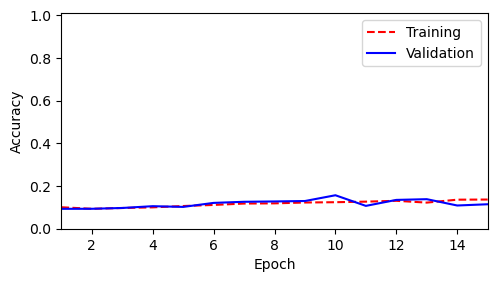

In [15]:
# evaluate
evaluate_model(name, model, eval_data)

### Now let's check if you fixed the issue!

Model0(
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (out): Linear(in_features=100, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)
Epoch 1: Loss 25.0111, Train Acc 72.62%, Val Loss 3.9348, Val Acc 69.50%
Epoch 2: Loss 2.0896, Train Acc 68.30%, Val Loss 1.2594, Val Acc 62.76%
Epoch 3: Loss 1.0086, Train Acc 66.27%, Val Loss 1.0448, Val Acc 65.62%
Epoch 4: Loss 0.8539, Train Acc 68.69%, Val Loss 1.0718, Val Acc 68.46%
Epoch 5: Loss 0.7920, Train Acc 69.70%, Val Loss 0.9058, Val Acc 68.84%
Epoch 6: Loss 0.7448, Train Acc 70.52%, Val Loss 1.0060, Val Acc 70.24%
Epoch 7: Loss 0.7339, Train Acc 71.27%, Val Loss 0.8341, Val Acc 70.02%
Epoch 8: Loss 0.6991, Train Acc 72.40%, Val Loss 0.8356, Val Acc 69.44%
Epoch 9: Loss 0.6919, Train Acc 72.44%, Val Loss 0.8030, Val Acc 70.50%
Epoch 10: Loss 0.6490, Train Acc 73.72%, Val Loss 0.8088, Val Acc 71.62%
Epoch 11: Loss 0.6298, Train Acc 75.46

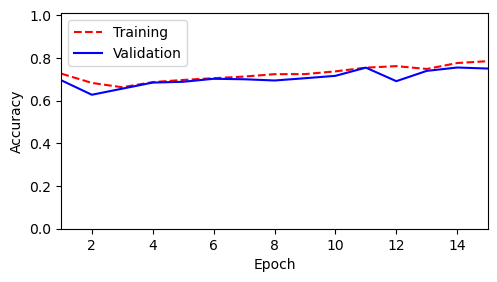

In [16]:
## create and compile the model for fixed=True, train it, then evaluate it
fixed = True
name, model = create_compile_model0(fixed, verbose=True) 

# train
eval_data = train_model(model, verbose=1, dataset=dataset)

# evaluate
evaluate_model(name, model, eval_data)

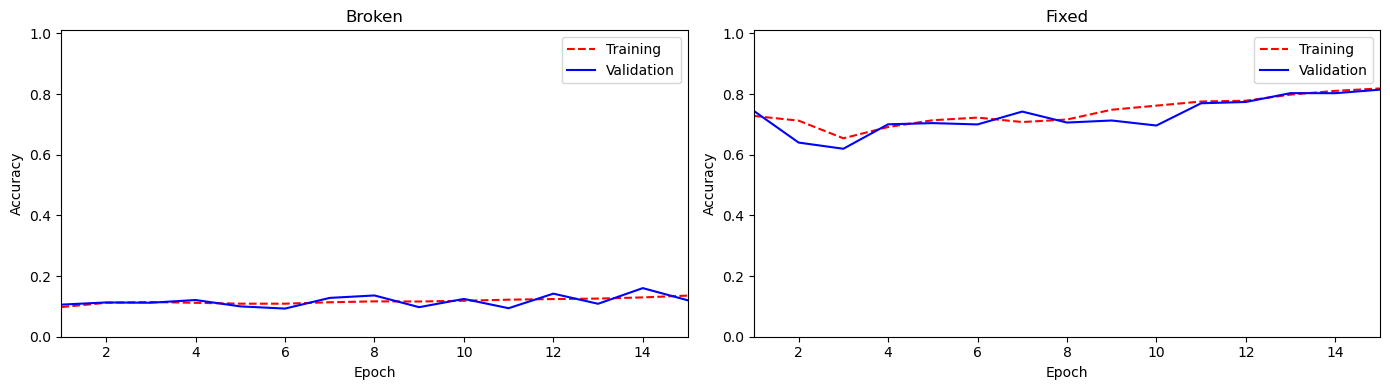

In [17]:
""" [ASSERTS] Check 2a completed. """

# Call compile_train_eval_compare with the dataset (make sure dataset is defined)
_, broken_model, _, broken_perf_data, _, fixed_model, _, fixed_perf_data = compile_train_eval_compare(create_compile_model0, dataset)

assert len(list(broken_model.children())) == len(list(fixed_model.children())), "The number of layers (child modules) should match."

broken_tracc = broken_perf_data[:, 1]
broken_valacc = broken_perf_data[:, 3]
fixed_tracc = fixed_perf_data[:, 1]
fixed_valacc = fixed_perf_data[:, 3]

assert np.amax(broken_valacc) < 0.55 and np.amax(fixed_valacc) > 0.625, "Validation accuracy thresholds not met."

### Does the model works as expected now? Does it achieve about 80%+ accuracy (or at least 75%+)?

### [Task 2b] (5 points) Just like task 2a, consider the following model. It has one obvious problem which prevents the model from learning: can you figure out what it is? Fix it by adding code to the 'if fixed:'' branch. Make sure that if fixed=False you do not change the implementation!

### Note: the model is different in some ways to model0 but most of these ways are unrelated to the problem you are asked to diagnose and fix!

In [18]:
def create_compile_model1(fixed, input_shape=784, num_outputs=10, verbose=True):
    
    """ Remove the raise NotImplementedError lines, then move the if fixed branch to where you want to use it, and create a corresponding else (if necessary) to preserve 
    the broken functionality when fixed=False. For example:
    #if fixed:
        ###* put your code here (~1-2 lines) *###
    
    Note: the 'raise NotImplementedError' lines may not match where you should put your 'if fixed' branch.
    """
    
    # YOUR CODE HERE
    
    name = 'Model1--Fixed' if fixed else 'Model1--Broken'
    hidden_widths = [256, 128, 48]

    class Model1(nn.Module):
        def __init__(self, input_shape, hidden_widths, num_outputs):
            super(Model1, self).__init__()
            
            layers = []
            in_features = input_shape
            
            # Build hidden layers: Dense layers (without bias) followed by ReLU activation.
            for i, hw in enumerate(hidden_widths):
                linear = nn.Linear(in_features, hw, bias=False)
                # Initialize weights with normal distribution (std = sqrt(1/hw))
                nn.init.normal_(linear.weight, mean=0.0, std=np.sqrt(1/hw))
                layers.append(linear)
                layers.append(nn.ReLU())
                in_features = hw
                
            self.hidden = nn.Sequential(*layers) # stack the layers in sequence
            
            # Final output layer: with bias (use_bias=True)
            self.output_layer = nn.Linear(in_features, num_outputs, bias=True)
            nn.init.normal_(self.output_layer.weight, mean=0.0, std=np.sqrt(0.1))
            nn.init.zeros_(self.output_layer.bias)
            
        def forward(self, x):
            x = self.hidden(x)
            x = self.output_layer(x)
            
            return x
    
    model = Model1(input_shape, hidden_widths, num_outputs)
    
    # YOUR CODE HERE
    
    # Set default optimizer learning rate
    opt_lr = 0.1
    # YOUR CODE HERE
    if fixed:
        opt_lr = 0.0005
    
    if verbose:
        print(model)

    model.loss_func = nn.CrossEntropyLoss()
    model.learning_rate = opt_lr
    
    return name, model

In [19]:
## create and compile the model for fixed=False, train it, then evaluate it
fixed = False
name, model = create_compile_model1(fixed) 

# train the model (hint you can set verbose to 1 to get more information during the training process)
eval_data = train_model(model, dataset=dataset)

Model1(
  (hidden): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=False)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=False)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=48, bias=False)
    (5): ReLU()
  )
  (output_layer): Linear(in_features=48, out_features=10, bias=True)
)


[Model1--Broken] Training Accuracy: 10.000%, Validation Accuracy: 9.720%
[Model1--Broken] Test loss: 2.30673, test accuracy: 10.280%


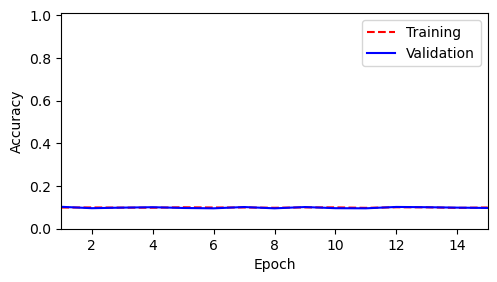

In [20]:
# evaluate
evaluate_model(name, model, eval_data)

### Let's check if you fixed the issue.

[Model1--Fixed] Training Accuracy: 76.247%, Validation Accuracy: 74.880%
[Model1--Fixed] Test loss: 0.68875, test accuracy: 74.740%


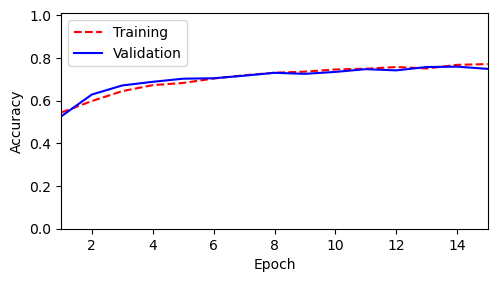

In [21]:
fixed = True
name, model = create_compile_model1(fixed, verbose=False) 

eval_data = train_model(model, dataset=dataset)
evaluate_model(name, model, eval_data)

In [22]:
""" [ASSERTS] Check 2b completed. """

assert var_exists('create_compile_model1') # note: hidden tests will check accuracy is high enough for Fixed=True.


### [Task 2c] (5 points) Explain what was the problem. (A sentence or two is fine.)

In [23]:
""" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"""
# 
## Answer: 
# The problem was that the learning rate was set too high, which prevented the model from training properly.
# Reducing it to a reasonable value allowed the optimizer to converge and the model to learn effectively.

# YOUR CODE HERE

#

" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"

### [Task 2d] (5 points) Just like task 2a and task 2b, consider the following model. It has one obvious problem which prevents the model from learning: can you figure out what it is? Fix it by adding code to the 'if fixed:'' branch. Make sure that if fixed=False you do not change the implementation!

In [24]:
def create_compile_model2(fixed, input_shape=784, num_outputs=10, verbose=True):
    
    """ Remove the raise NotImplementedError lines, then move the if fixed branch to where you want to use it, and create a corresponding else (if necessary) to preserve 
    the broken functionality when fixed=False. For example:
    #if fixed:
        ###* put your code here (~1-2 lines) *###
    
    Note: the 'raise NotImplementedError' lines may not match where you should put your 'if fixed' branch.
    """
    
    # YOUR CODE HERE
    
    name = 'Model2--Fixed' if fixed else 'Model2--Broken'
    hidden_widths = [400, 96]
  
    
    class Model2(nn.Module):
        def __init__(self, input_shape, hidden_widths, num_outputs):
            super(Model2, self).__init__()
            
            # Hidden layers: using bias=True
            self.hidden1 = nn.Linear(input_shape, hidden_widths[0], bias=True)
            self.hidden2 = nn.Linear(hidden_widths[0], hidden_widths[1], bias=True)
            # Output layer: use_bias=False
            self.output_layer = nn.Linear(hidden_widths[1], num_outputs, bias=False)
            
            # YOUR CODE HERE
            
            # Initialize hidden layers: here we use a normal-like initialization similar to Keras
            nn.init.normal_(self.hidden1.weight, mean=0.0, std=np.sqrt(1/hidden_widths[0]))
            nn.init.zeros_(self.hidden1.bias)
            nn.init.normal_(self.hidden2.weight, mean=0.0, std=np.sqrt(1/hidden_widths[1]))
            nn.init.zeros_(self.hidden2.bias)
            
            # Initialize output layer: normal with std = sqrt(0.1)
            nn.init.normal_(self.output_layer.weight, mean=0.0, std=np.sqrt(0.1))
            
        def forward(self, x):
            x = F.relu(self.hidden1(x))
            x = F.relu(self.hidden2(x))
            x = self.output_layer(x)
            return x

    model = Model2(input_shape, hidden_widths, num_outputs)
    
    # YOUR CODE HERE
    
    # Set up the optimizer using RMSprop.
    opt_lr = 1e-8
    # YOUR CODE HERE
    if fixed:
        opt_lr = 0.001
    optimizer = optim.RMSprop(model.parameters(), lr=opt_lr)
    
    if verbose:
        print(model)
    

    model.loss_func = nn.CrossEntropyLoss()
    model.optimizer = optimizer
    model.learning_rate = opt_lr
    
    return name, model

In [25]:
# create and compile the model for fixed=False, train it, then evaluate it
fixed = False
name, model = create_compile_model2(fixed) 

# train the model (hint you can set verbose to 1 to get more information during the training process)
eval_data = train_model(model, dataset=dataset)

Model2(
  (hidden1): Linear(in_features=784, out_features=400, bias=True)
  (hidden2): Linear(in_features=400, out_features=96, bias=True)
  (output_layer): Linear(in_features=96, out_features=10, bias=False)
)


[Model2--Broken] Training Accuracy: 15.612%, Validation Accuracy: 15.800%
[Model2--Broken] Test loss: 668.51691, test accuracy: 15.820%


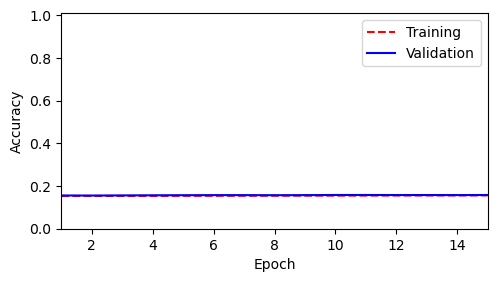

In [26]:
# evaluate
evaluate_model(name, model, eval_data)

### Let's check if you fixed the issue.

[Model2--Fixed] Training Accuracy: 85.608%, Validation Accuracy: 83.200%
[Model2--Fixed] Test loss: 0.50896, test accuracy: 84.220%


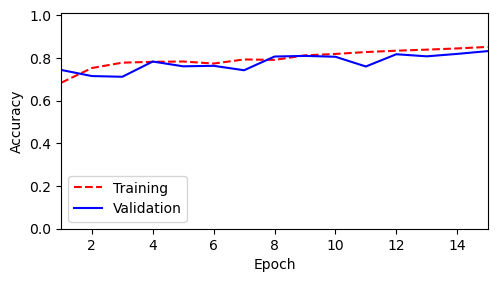

In [27]:
fixed = True
name, model = create_compile_model2(fixed, verbose=False)

eval_data = train_model(model, dataset=dataset)
evaluate_model(name, model, eval_data)

In [28]:
""" [ASSERTS] Check 2d completed. """
assert var_exists('create_compile_model2') # note: hidden tests will check accuracy is high enough for Fixed=True.


### [Task 2e] (5 points) Explain what was the problem. (A sentence or two is fine.)

In [29]:
""" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"""
# 
## Answer: 
# The problem was that the learning rate was set far too small, so the optimizer made almost no progress.
# Increasing the learning rate allowed the model parameters to update enough for the network to learn.
# YOUR CODE HERE
#

" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"

## [Task 3] (30 points) Diagnosing Other Problems
### Note: just as before we are looking for ways to fix a problem in minimal ways. Of course, we can always fix an issue by completely changing the model create code, but that's not the goal. The problem is one small thing, so we are looking for a simple and small change to fix it.

### [Task 3a] (5 points) Just like in task 2, consider the following model. It has one obvious problem which prevents the model from learning: can you figure out what it is? Fix it by adding code to the 'if fixed:'' branch. Make sure that if fixed=False you do not change the implementation!
### Note: the problem is *not* with the optimizer or the learning rate. Do not change that part.

In [30]:
def create_compile_model3(fixed, input_shape=784, num_outputs=10, verbose=True):
    
    """ Remove the raise NotImplementedError lines, then move the if fixed branch to where you want to use it, and create a corresponding else (if necessary) to preserve 
    the broken functionality when fixed=False. For example:
    #if fixed:
        ###* put your code here (~1-2 lines) *###
    
    Note: the 'raise NotImplementedError' lines may not match where you should put your 'if fixed' branch.
    """
    
    # YOUR CODE HERE
    
    name = 'Model3--Fixed' if fixed else 'Model3--Broken'
    hidden_widths = [512, 128, 32, 24]
    
    # YOUR CODE HERE
    
    class Model3(nn.Module):
        def __init__(self, input_shape, hidden_widths, num_outputs, fixed):
            super(Model3, self).__init__()
            
            layers = []
            in_features = input_shape
            
            for i, hw in enumerate(hidden_widths):
                linear = nn.Linear(in_features, hw, bias=True)
                # Initialize weights with RandomNormal(stddev=0.001)
                nn.init.normal_(linear.weight, mean=0.0, std=0.001)
                nn.init.normal_(linear.bias, mean=0.0, std=0.001)
                layers.append(linear)
                layers.append(nn.ReLU())
                in_features = hw
                
            self.hidden = nn.Sequential(*layers)
            self.fixed = fixed
            
            # Create output layer with use_bias=True
            self.output_layer = nn.Linear(in_features, num_outputs, bias=True)
            nn.init.normal_(self.output_layer.weight, mean=0.0, std=np.sqrt(0.1))
            nn.init.zeros_(self.output_layer.bias)
            
        def forward(self, x):
            if self.fixed:
                # YOUR CODE HERE
                x = self.hidden(x)
                x = self.output_layer(x)
                return x
            else:
                x = self.hidden(x)
                x = self.output_layer(x)
                x = torch.softmax(x,dim=1)
                return x
           
    
    model = Model3(input_shape, hidden_widths, num_outputs, fixed)

    # note: the problem is *not* with the optimizer or the learning rate.
    opt = optim.Adam(model.parameters(), lr=0.004, betas=(0.9, 0.995), eps=1e-07, amsgrad=False)
    if verbose:
        print(model)
    model.loss_func = nn.CrossEntropyLoss()
    model.optimizer = opt
        
    # YOUR CODE HERE
    
    return name, model

In [31]:
# create and compile the model for fixed=False, train it, then evaluate it
name, model = create_compile_model3(False) 

# train the model (hint you can set verbose get more or less information during the training process)
eval_data = train_model(model, verbose=1, dataset=dataset)

Model3(
  (hidden): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=24, bias=True)
    (7): ReLU()
  )
  (output_layer): Linear(in_features=24, out_features=10, bias=True)
)
Epoch 1: Loss 2.0909, Train Acc 36.45%, Val Loss 2.1025, Val Acc 35.92%
Epoch 2: Loss 2.1247, Train Acc 33.62%, Val Loss 2.0987, Val Acc 36.34%
Epoch 3: Loss 2.1326, Train Acc 32.89%, Val Loss 2.1579, Val Acc 30.40%
Epoch 4: Loss 2.1437, Train Acc 31.75%, Val Loss 2.1872, Val Acc 27.42%
Epoch 5: Loss 2.2655, Train Acc 19.56%, Val Loss 2.2712, Val Acc 18.96%
Epoch 6: Loss 2.2693, Train Acc 19.18%, Val Loss 2.2787, Val Acc 18.22%
Epoch 7: Loss 2.2709, Train Acc 19.05%, Val Loss 2.2813, Val Acc 17.96%
Epoch 8: Loss 2.2780, Train Acc 18.32%, Val Loss 2.2717, Val Acc 18.88%
Epoch 9:

[Model3--Broken] Training Accuracy: 10.000%, Validation Accuracy: 9.620%
[Model3--Broken] Test loss: 2.35735, test accuracy: 10.380%


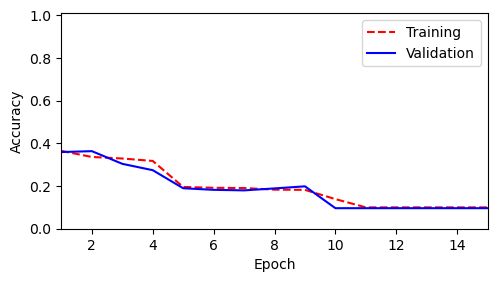

In [32]:
# evaluate
evaluate_model(name, model, eval_data)

### Let's check if you fixed the issue. Note: for this task (3a) the broken model can sometimes achieve fairly high accuracy (e.g., 60%), but that's not good enough. Your fixed model should get 85%+ accuracy.

[Model3--Fixed] Training Accuracy: 88.567%, Validation Accuracy: 85.820%
[Model3--Fixed] Test loss: 0.41080, test accuracy: 85.840%


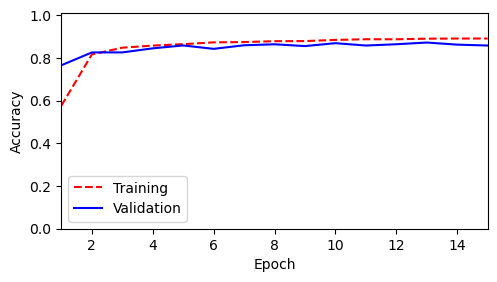

In [33]:
name, model = create_compile_model3(True, verbose=False) 

eval_data = train_model(model, dataset=dataset)
evaluate_model(name, model, eval_data)

In [34]:
""" [ASSERTS] Check 3a completed. """

assert var_exists('create_compile_model3') # note: hidden tests will check accuracy is high enough for Fixed=True.


###  [Task 3b] (5 points) Explain what was the problem. (One sentence or two is fine.)

In [35]:
""" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"""
# 
## Answer: 
# The model applied softmax before CrossEntropyLoss, but CrossEntropyLoss expects raw logits.
# Removing softmax from the fixed forward pass allows the loss to work correctly and improves learning.
# YOUR CODE HERE
#

" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"

### [Task 3c] (5 points) Consider the following model. It has one obvious problem which prevents the model from learning: can you figure out what it is? Fix it by adding code to the 'if fixed:'' branch. Make sure that if fixed=False you do not change the implementation!

In [36]:
def create_compile_model4(fixed, input_shape=784, num_outputs=10, verbose=True):
    
    """ Remove the raise NotImplementedError lines, then move the if fixed branch to where you want to use it, and create a corresponding else (if necessary) to preserve 
    the broken functionality when fixed=False. For example:
    #if fixed:
        ###* put your code here (~1-2 lines) *###
    
    Note: the 'raise NotImplementedError' lines may not match where you should put your 'if fixed' branch.
    """
    
    # YOUR CODE HERE
    
    name = 'Model4--Fixed' if fixed else 'Model4--Broken'
    if fixed:
        hidden_widths = [512, 128, 32, 24]
    else:
        hidden_widths = [512, 128, 3, 24]
    
    # YOUR CODE HERE

    
    class Model4(nn.Module):
        def __init__(self, input_shape, hidden_widths, num_outputs):
            super(Model4, self).__init__()
            
            layers = []
            in_features = input_shape
            
            for i, hw in enumerate(hidden_widths):
                # Create a dense (linear) layer with bias
                layers.append(nn.Linear(in_features, hw, bias=True))
                layers.append(nn.ReLU())
                in_features = hw
            self.hidden = nn.Sequential(*layers)
            
            # Create output layer with bias=True
            self.output_layer = nn.Linear(in_features, num_outputs, bias=True)
            # Initialize output layer weights with RandomNormal(stddev=sqrt(0.1)) and biases with zeros
            nn.init.normal_(self.output_layer.weight, mean=0.0, std=np.sqrt(0.1))
            nn.init.zeros_(self.output_layer.bias)
            
        def forward(self, x):
            x = self.hidden(x)
            x = self.output_layer(x)
            
            return x

    model = Model4(input_shape, hidden_widths, num_outputs)
    
    # YOUR CODE HERE
    
    opt = optim.NAdam(model.parameters(), lr=0.001)
    
    # YOUR CODE HERE
    
    if verbose:
        print(model)

    model.loss_func = nn.CrossEntropyLoss()
    model.optimizer = opt
    
    return name, model

In [37]:
# create and compile the model for fixed=False, train it, then evaluate it
name, model = create_compile_model4(False) 

# train the model (hint you can set verbose get more or less information during the training process)
eval_data = train_model(model, verbose=1, dataset=dataset)

Model4(
  (hidden): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
    (5): ReLU()
    (6): Linear(in_features=3, out_features=24, bias=True)
    (7): ReLU()
  )
  (output_layer): Linear(in_features=24, out_features=10, bias=True)
)
Epoch 1: Loss 2.3188, Train Acc 10.05%, Val Loss 2.3027, Val Acc 10.20%
Epoch 2: Loss 2.3029, Train Acc 9.96%, Val Loss 2.3027, Val Acc 9.62%
Epoch 3: Loss 2.3028, Train Acc 10.02%, Val Loss 2.3027, Val Acc 9.56%
Epoch 4: Loss 2.3028, Train Acc 10.03%, Val Loss 2.3028, Val Acc 9.56%
Epoch 5: Loss 2.3028, Train Acc 10.05%, Val Loss 2.3027, Val Acc 9.88%
Epoch 6: Loss 2.3029, Train Acc 9.84%, Val Loss 2.3026, Val Acc 10.44%
Epoch 7: Loss 2.3029, Train Acc 9.83%, Val Loss 2.3027, Val Acc 10.08%
Epoch 8: Loss 2.3028, Train Acc 9.84%, Val Loss 2.3027, Val Acc 10.08%
Epoch 9: Loss 2.30

[Model4--Broken] Training Accuracy: 10.000%, Validation Accuracy: 10.080%
[Model4--Broken] Test loss: 2.30265, test accuracy: 9.920%


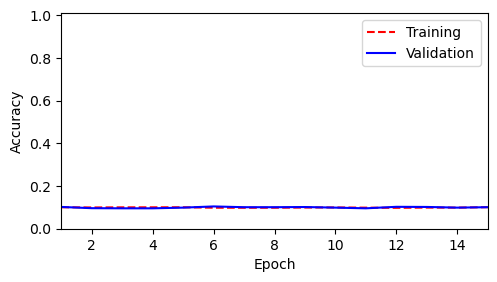

In [38]:
# evaluate
evaluate_model(name, model, eval_data)

### Let's check if you fixed the issue.

[Model4--Fixed] Training Accuracy: 90.372%, Validation Accuracy: 86.780%
[Model4--Fixed] Test loss: 0.41847, test accuracy: 86.540%


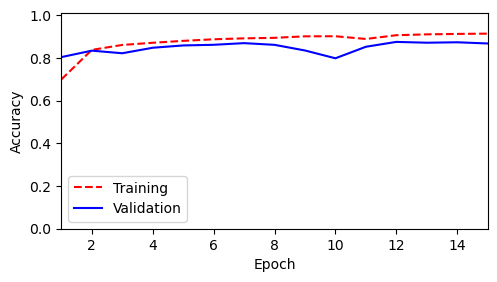

In [39]:
name, model = create_compile_model4(True, verbose=False) 

eval_data = train_model(model, dataset=dataset)
evaluate_model(name, model, eval_data)

In [40]:
""" [ASSERTS] Check 3c completed. """

assert var_exists('create_compile_model4') # note: hidden tests will check accuracy is high enough for Fixed=True.


### [Task 3d] (5 points) Explain what was the problem. (A sentence or two is fine.)

In [41]:
""" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"""
# 
## Answer: 
# The model had an extreme hidden bottleneck of width 3, which compressed the representation too much.
# Increasing that hidden layer width allowed the network to retain useful information and learn effectively.
# YOUR CODE HERE

#

" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"

### [Task 3e] (5 points) Consider the following model. It has several problems which prevent it from learning: can you figure out what those problems are? Fix them by adding code to the 'if fixed:'' branch. Make sure that if fixed=False you do not change the implementation! You can have more than one "if fixed:" branch if necessary.

In [42]:
def create_compile_model5(fixed, input_shape=784, num_outputs=10, verbose=True):
    
    """ Remove the raise NotImplementedError lines, then move the if fixed branch to where you want to use it, and create a corresponding else (if necessary) to preserve 
    the broken functionality when fixed=False. For example:
    #if fixed:
        ###* put your code here (~1-2 lines) *###
    
    Note: the 'raise NotImplementedError' lines may not match where you should put your 'if fixed' branch.
    """
    
    # YOUR CODE HERE
    
    name = 'Model5--Fixed' if fixed else 'Model5--Broken'
    hidden_widths = [256, 128, 24]

    
    # YOUR CODE HERE
    
    # Define the custom model
    class Model5(nn.Module):
        def __init__(self, input_shape, hidden_widths, num_outputs, fixed):
            super(Model5, self).__init__()
            self.fixed = fixed
            
            layers = []
            in_features = input_shape
            
            # Build hidden layers
            for i, hw in enumerate(hidden_widths):
                layer = nn.Linear(in_features, hw)
                layers.append(layer)
                # YOUR CODE HERE
                if fixed:
                    layers.append(nn.ReLU())
                if not fixed:
                    layers.append(nn.Sigmoid())
                in_features = hw
                
            self.hidden = nn.Sequential(*layers)
            
            # Output layer
            if fixed:
                # YOUR CODE HERE
                self.output_layer = nn.Linear(in_features, num_outputs, bias=True)
            else:
                
                self.output_layer = nn.Linear(in_features, num_outputs, bias=False)
            
            if fixed:
                # YOUR CODE HERE
                nn.init.normal_(self.output_layer.weight, mean=0.0, std=np.sqrt(0.1))
                nn.init.zeros_(self.output_layer.bias)
            else:
                
                nn.init.zeros_(self.output_layer.weight)
                
        def forward(self, x):
            x = self.hidden(x)
            x = self.output_layer(x)
            # YOUR CODE HERE
            if fixed:
                return x
            if not fixed:
                x = torch.softmax(x,dim=1) 
                return x
    
    model = Model5(input_shape, hidden_widths, num_outputs, fixed)
    
    # YOUR CODE HERE
    if fixed:
        opt = optim.NAdam(model.parameters(), lr=0.001, betas=(0.9, 0.995), eps=1e-07)
    if not fixed:
        opt = optim.NAdam(model.parameters(), lr=0.01, betas=(0.9, 0.999), eps=1e-07)
    
    if verbose:
        print(model)
    
    model.loss_func = nn.CrossEntropyLoss()
    model.optimizer = opt
    
    return name, model

In [43]:
# create and compile the model for fixed=False, train it, then evaluate it
name, model = create_compile_model5(False) 

# train the model (hint you can set verbose get more or less information during the training process)
eval_data = train_model(model, verbose=0, dataset=dataset)

Model5(
  (hidden): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=128, out_features=24, bias=True)
    (5): Sigmoid()
  )
  (output_layer): Linear(in_features=24, out_features=10, bias=False)
)


[Model5--Broken] Training Accuracy: 43.787%, Validation Accuracy: 42.740%
[Model5--Broken] Test loss: 2.02613, test accuracy: 43.660%


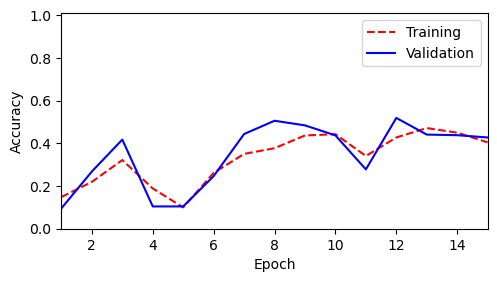

In [44]:
# evaluate
evaluate_model(name, model, eval_data)

### Let's check if you fixed the issue.

[Model5--Fixed] Training Accuracy: 90.145%, Validation Accuracy: 86.560%
[Model5--Fixed] Test loss: 0.41622, test accuracy: 86.720%


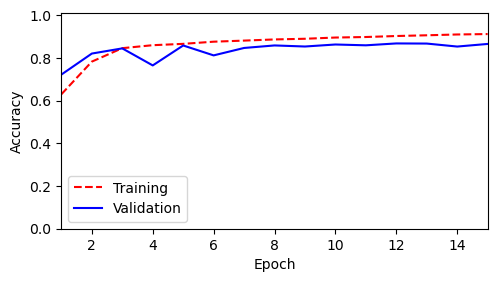

In [45]:
name, model = create_compile_model5(True, verbose=False) 

eval_data = train_model(model, dataset=dataset)
evaluate_model(name, model, eval_data)

In [46]:
""" [ASSERTS] Check 3e completed. """

assert var_exists('create_compile_model5') # note: hidden tests will check accuracy is high enough for Fixed=True.


### [Task 3f] (5 points) Explain what was the problem. If there are multiple issues, describe all of them. (A sentence or two for each issue is fine.)

In [47]:
""" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"""
# 
## Answer: 
# The broken model had several problems: it used sigmoid activations in the hidden layers, the output layer had no bias,
# the output weights were initialized to all zeros, and it applied softmax before CrossEntropyLoss.
# I fixed it by using ReLU hidden activations, giving the output layer a bias, using a nonzero random initialization,
# returning raw logits, and using a more reasonable learning rate.
# YOUR CODE HERE
#

" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"

---
# [Task 4] (25 points) Training CNNs

### In this task, you will train a convolutional neural network with an architecture you define. The goal is (of course) to train the best possible model, but the constraint is that the number of parameters must not exceed 500k (500,000). We will aim to achieve test/val accuracy above 88%.

### If you do this on a machine with a GPU, it will be very fast. Otherwise it may take 5 or 10 minutes to train the model for a few epochs, so we will use a subset of the training data for developing and testing the model.

#### Note: it is possible to achieve reasonably high accuracy (above 90%) with only about 50k parameters.

### To use a convolutional architecture we need to reshape the data

In [56]:
use_subset = True
tr_sz = 5000

use_subset = False # uncomment this line to use the full data
# YOUR CODE HERE


train_x = train_x.reshape(-1, 1, 28, 28)
val_x = val_x.reshape(-1, 1, 28, 28)
test_x = test_x.reshape(-1, 1, 28, 28)

cnn_dataset = (train_x, train_y, val_x, val_y, test_x, test_y)
if use_subset:
    cnn_dataset = (train_x[:tr_sz], train_y[:tr_sz], val_x, val_y, test_x, test_y)

### [Task 4a] (15 points) Fill in the implementation of create_compile_cnn() below with your chosen architecture. Ensure the total number of parameters chosen does not exceed 500k. You can look for insipiration for architectures on the web (or in books) if you like, but in that case you must provide a reference.

In [57]:
def create_compile_cnn(input_shape=(28, 28, 1), num_outputs=10, verbose=False):
    name = 'CNN'

    if input_shape[-1] == 1:
        pt_input_shape = (1, input_shape[0], input_shape[1])
    else:
        pt_input_shape = input_shape

    """ 
    Put your code here (10-20 lines).
    You can use any architecture. Do not apply softmax to output layer, since nn.CrossEntropyLoss expects raw logits.
    You can also use whatever optimizer 'opt' you want (with your choice hyperparameters values)
    But the call to model.summary() must show that the number of parameters is within the constraint.
    """
    
    ###* put your code here (~10-20 lines) *###
    class CNN(nn.Module):
        def __init__(self, num_outputs):
            super(CNN, self).__init__()

            self.features = nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),

                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )

            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(64 * 7 * 7, 128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, num_outputs)
            )

        def forward(self, x):
            x = self.features(x)
            x = self.classifier(x)
            return x

    model = CNN(num_outputs)
    
    # YOUR CODE HERE
    
    if verbose:
        print(model)

    opt = optim.Adam(model.parameters(), lr=0.001)
    model.optimizer = opt
    model.loss_func = nn.CrossEntropyLoss()
    
    return name, model

In [58]:
name, cnn_model = create_compile_cnn(verbose=True)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [59]:
# note: you can change the number of epochs to train as long as it's reasonable
epochs = 10 if use_subset else 5

""" You can add code here or edit it to change the number of epochs for example or the batch size, etc.
"""
# YOUR CODE HERE

# note: you can change how you call train_model as necessary (e.g., if you want to change the batch_size)
eval_data = train_model(cnn_model, max_epochs=epochs, dataset=cnn_dataset, verbose=1)

Epoch 1: Loss 0.9912, Train Acc 79.43%, Val Loss 0.3570, Val Acc 86.88%
Epoch 2: Loss 0.3386, Train Acc 87.78%, Val Loss 0.3133, Val Acc 88.38%
Epoch 3: Loss 0.2987, Train Acc 89.00%, Val Loss 0.2960, Val Acc 89.56%
Epoch 4: Loss 0.2744, Train Acc 89.91%, Val Loss 0.2912, Val Acc 89.62%
Epoch 5: Loss 0.2549, Train Acc 90.57%, Val Loss 0.2862, Val Acc 90.04%


#### Let's evaluate your CNN model. Does it achieve 86+% val/test accuracy?
#### *note: once you are confident in your model architecture, you MUST switch back to the full dataset*
#### to train the final version of the model (depending on your chosen architecture this could take 5-10 minutes if you are not on machine with GPU)
#### make sure it does not take too long to train the model as this could be a problem for grading (e.g., <10min on a machine with a CPU only)

[CNN] Training Accuracy: 92.687%, Validation Accuracy: 90.040%
[CNN] Test loss: 0.26974, test accuracy: 90.000%


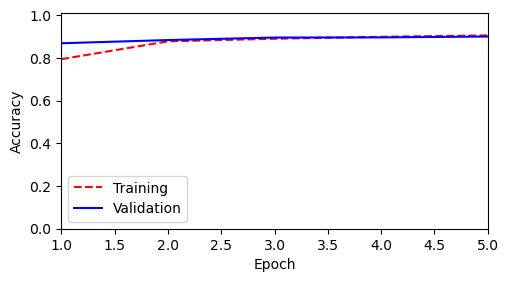

In [60]:
evaluate_model(name, cnn_model, eval_data)

In [61]:
import torch.nn as nn

""" [ASSERTS] Check 4a completed. """

assert var_exists('cnn_model') and isinstance(cnn_model, nn.Module)
trainable_count = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
assert trainable_count <= 500 * 1000



### [Task 4b] (5 points) How long (in seconds/minutes) did your model take to train on the full dataset? Did you use a GPU?

In [62]:
""" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"""
# 
## Answer: 
# The model took about 1 minute 40 seconds to train on the full dataset.
# I didn't use a GPU, only the CPU.

# YOUR CODE HERE



" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"

### [Task 4c] (5 points) Explain how you decided on this architecture. (2-3 sentences is okay.) If you took inspiration from resources such as books/webpages, it's okay but you should (of course) include a citation/reference in your answer.

In [63]:
""" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"""
# 
## Answer: 
# I chose a compact CNN with two convolutional layers and max-pooling followed by a small fully connected classifier.
# This architecture can learn useful local image features from Fashion-MNIST while keeping the parameter count under 500,000 and training time low.
# I selected it because it gave strong validation/test accuracy without making the model unnecessarily large or slow.

# YOUR CODE HERE
#

" Remove the 'raise NotImplementedError' line(s). Write your answer as a comment in the place provided.  (Do not change the cell type from code to markdown.)"